# Resume2Roles

## Main project - for analysis purposes 



---



## Authors:
* Ethan Eckmann
* Eddie Lin
* Henry Wei
* Neha Indolikar



---



## Description:
This project is a Natural Language Processing system that parses resumes to extract relevant information such as skills, experience, education, etc. to return a ranked list of the best matching job roles sourced from Linkedin job postings for a given candidate. Job roles are ranked by the Cosine Similarity scores between the resume and job postings in the dataset to quantify how well a candidate matches a given job role.

Multiple text vectorization methods are analysed:

TF-IDF, Word2Vec, GloVe, and Sentence BERT


In [52]:
import importlib.util
import os
import subprocess
import sys

def install_and_import(package_name):
    """
    Checks if a package is installed. If not, installs it and then imports it.
    """
    # Check if the package is already installed
    spec = importlib.util.find_spec(package_name)

    if spec is None:
        print(f"{package_name} not found. Installing...")
        try:
            # Use sys.executable to ensure it's installed in the correct environment
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
            print(f"Successfully installed {package_name}")
        except subprocess.CalledProcessError as e:
            print(f"Failed to install {package_name}: {e}")
            return None
    else:
        print(f"{package_name} is already installed.")

    # Import the package programmatically
    return importlib.import_module(package_name)

install_and_import('bert_score')
install_and_import('kagglehub')
install_and_import('nltk')
install_and_import('sklearn')
install_and_import('wordcloud')
install_and_import('gensim')
install_and_import('sentence_transformers')
install_and_import('torch')
install_and_import('zipfile')
install_and_import('joblib')

# libraries
import pandas as pd
import kagglehub
import shutil
import gensim.downloader as api
import numpy as np
import joblib
import scipy.sparse as sp


import nltk
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from gensim.models import Word2Vec

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers.util import cos_sim as cosine_similarity_sbert


bert_score is already installed.
kagglehub is already installed.
nltk is already installed.
sklearn is already installed.
wordcloud is already installed.
gensim is already installed.
sentence_transformers is already installed.
torch is already installed.
zipfile is already installed.
joblib is already installed.


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ethan_skpfc39\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ethan_skpfc39\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ethan_skpfc39\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data loading and Preprocessing

In [53]:
# Function to handle dataset download and aliasing
def download_and_alias_dataset(dataset_id, target_alias_path):
    path = kagglehub.dataset_download(dataset_id)
    # Check if the target alias path already exists
    if not os.path.exists(target_alias_path):
        # kagglehub.dataset_download usually returns the path to a directory.
        # shutil.move attempts os.rename first, which fails across different filesystems (e.g., /kaggle/input to /content).
        # It then falls back to copying the contents and trying to delete the original source.
        # The '/kaggle/input' filesystem is read-only, so the deletion step fails with OSError 30.
        # To fix this, we should directly copy the directory using shutil.copytree,
        # which doesn't attempt to delete the source.
        shutil.copytree(path, target_alias_path)

In [54]:
# loading non-preprocessed datasets
# if datasets are not in the local directory, load them
import os
import numpy as np

data_directory_path = 'datasets'

# Joining paths ensures it works on both Windows and Mac/Linux
file_path_1 = os.path.join(data_directory_path, 'postings.csv')
file_path_2 = os.path.join(data_directory_path, 'resumes.csv')

if not os.path.isfile(file_path_1) or not os.path.isfile(file_path_2):
    # Download and preprocess datasets
    print("Missing data files. Downloading from Kaggle")
    download_and_alias_dataset("arshkon/linkedin-job-postings", '/content/arshkon_linkedin-job-postings')
    download_and_alias_dataset("saugataroyarghya/resume-dataset", '/content/saugataroyarghya_resume-dataset')

    job_df = pd.read_csv('/content/arshkon_linkedin-job-postings/postings.csv')
    resume_df = pd.read_csv('/content/saugataroyarghya_resume-dataset/resume_data.csv')

    # fix error (hidden character (a Byte Order Mark or BOM))
    resume_df.rename(columns={'\ufeffjob_position_name': 'job_position_name'}, inplace=True)

    # select columns to use
    job_df = job_df[['description', 'title']]
    resume_df['combined'] = resume_df['career_objective'] + resume_df['skills'] + resume_df['major_field_of_studies']
    resume_df = resume_df[['combined', 'job_position_name']]

    # Convert literal empty strings ('') to NaN
    resume_df['combined'] = resume_df['combined'].replace('', np.nan)
    job_df['description'] = job_df['description'].replace('', np.nan)

    # Drop any rows that have NaN in the text columns
    resume_df.dropna(subset=['combined'], inplace=True)
    job_df.dropna(subset=['description'], inplace=True)

    print(f"Rows remaining in resume_df: {len(resume_df)}")
    print(f"Rows remaining in job_df: {len(job_df)}")

    # Create "datasets" directory if it doesn't exist
    if not os.path.exists(data_directory_path):
        os.makedirs(data_directory_path)

    # save datasets
    job_df.to_csv(file_path_1, index=False)
    resume_df.to_csv(file_path_2, index=False)

else:
    # load datasets
    print("Loading datasets from local")
    job_df = pd.read_csv(file_path_1)
    resume_df = pd.read_csv(file_path_2)

Loading datasets from local


In [55]:
# overview of datasets function
def df_overview(df, df_var_name):
  # name of dataframe and an example of one row
  print(df_var_name)
  print("Example row:")
  print(df.head(1))

  # number of rows and columns
  print(f"There are {df.shape[0]} rows")
  print(f"There are {df.shape[1]} columns")

  # datatypes of columns
  print("Datatypes:")
  print(df.dtypes)
  print("\n")

  # number of nulls in each column
  print("Nulls:")
  null_values_in_data = df.isnull().sum()
  print(null_values_in_data)

  print("Samples (5)")
  print(df.sample(n=5))

  print("\n")

In [56]:
# Preprocess function
def preprocess(text):

  if not isinstance(text, str):
    return ""

  # Map special tech skills to text equivalents so they aren't destroyed by punctuation removal
  text = text.replace('c++', 'cplusplus')
  text = text.replace('c#', 'csharp')
  text = text.replace('.net', 'dotnet')
  text = text.replace('f#', 'fsharp')

  # Safely remove all special characters (reverting to your original safe regex)
  text = re.sub(r'[^a-z0-9\s]', '', text)



  tokens = text.split()
  tokens = [token for token in tokens if token not in stop_words]
  tokens = [lemmatizer.lemmatize(t) for t in tokens]
  return " ".join(tokens)

In [57]:
# loading preprocessed datasets
# if datasets are not in the local directory, load them
import os
import numpy as np

data_directory_path = 'datasets'

# Joining paths ensures it works on both Windows and Mac/Linux
file_path_3 = os.path.join(data_directory_path, 'postings_processed.csv')
file_path_4 = os.path.join(data_directory_path, 'resumes_processed.csv')

if not os.path.isfile(file_path_3) or not os.path.isfile(file_path_4):
    # Preprocess datasets
    print("Preprocessing datasets")
   
    # apply preprocessing on the text blob of the job applications
    job_df_processed = job_df.copy()
    job_df_processed['description'] = job_df_processed['description'].apply(preprocess)

    # apply preprocessing on the text blob of the resumes
    resume_df_processed = resume_df.copy()
    resume_df_processed['combined'] = resume_df_processed['combined'].apply(preprocess)

    # Convert literal empty strings ('') to NaN
    resume_df_processed['combined'] = resume_df_processed['combined'].replace('', np.nan)
    job_df_processed['description'] = job_df_processed['description'].replace('', np.nan)

    # Drop any rows that have NaN in the text columns
    resume_df_processed.dropna(subset=['combined'], inplace=True)
    job_df_processed.dropna(subset=['description'], inplace=True)

    print(f"Rows remaining in resume_df_processed: {len(resume_df_processed)}")
    print(f"Rows remaining in job_df_processed: {len(job_df_processed)}")

    # save preprocessed datasets
    job_df_processed.to_csv(file_path_3, index=False)
    resume_df_processed.to_csv(file_path_4, index=False)

else:
    # load preprocessed datasets
    print("Loading preprocessed datasets from local")
    job_df_processed = pd.read_csv(file_path_3)
    resume_df_processed = pd.read_csv(file_path_4)

Loading preprocessed datasets from local


In [58]:
# Sync the original dataframes using the indices of the processed
resume_df = resume_df.loc[resume_df_processed.index]
job_df = job_df.loc[job_df_processed.index]

print("Syncing dataset sizes")
print(f"Rows remaining in resume_df: {len(resume_df)}")
print(f"Rows remaining in job_df: {len(job_df)}")
print(f"Rows remaining in resume_df_processed: {len(resume_df_processed)}")
print(f"Rows remaining in job_df_processed: {len(job_df_processed)}")

Syncing dataset sizes
Rows remaining in resume_df: 4712
Rows remaining in job_df: 123839
Rows remaining in resume_df_processed: 4712
Rows remaining in job_df_processed: 123839


# Exploration of dataset structure

Two datasets

---

job postings dataset

dataframe name: job_df

https://www.kaggle.com/datasets/arshkon/linkedin-job-postings

---

resume dataset

dataframe name: resume_df

https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset


In [59]:
df_overview(job_df, "job_df https://www.kaggle.com/datasets/arshkon/linkedin-job-postings")

job_df https://www.kaggle.com/datasets/arshkon/linkedin-job-postings
Example row:
                                         description                  title
0  Job descriptionA leading real estate firm in N...  Marketing Coordinator
There are 123839 rows
There are 2 columns
Datatypes:
description    object
title          object
dtype: object


Nulls:
description    0
title          0
dtype: int64
Samples (5)
                                              description  \
113768  Join us in pioneering breakthroughs in healthc...   
113454  Our data centers are the foundation upon which...   
99195   Title: BCBA-Raleigh, NC\n\nA prestigious organ...   
27685   Employment Type\n\nPart time\n\nShift\n\nEveni...   
100463  Job Title: Anaplan Developer\nLocations: USA R...   

                                                    title  
113768            Time Specialist - HR Service Transition  
113454  Program Manager, Business Strategy & Planning,...  
99195            Board Certified Behavio

In [60]:
df_overview(job_df_processed, "job_df_processed")

job_df_processed
Example row:
                                         description                  title
0  ob description leading real estate firm ew ers...  Marketing Coordinator
There are 123839 rows
There are 2 columns
Datatypes:
description    object
title          object
dtype: object


Nulls:
description    0
title          0
dtype: int64
Samples (5)
                                              description  \
110204  uild best future ohnson ontrols team global le...   
7838    ob escription offer ompetitive starting wage t...   
6748    hat xpect esla otors looking ervice ssistant w...   
92973   ypsum anagement upply nc leading orth merican ...   
81515   ept per pay period 0 chedule 7 330 emporary po...   

                                                    title  
110204  Life Safety Systems Sales Representative, Elec...  
7838               Residential Field Sales Representative  
6748                                    Service Assistant  
92973          CDL Delivery Driv

In [61]:
df_overview(resume_df, "resume_df https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset")

resume_df https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset
Example row:
                                            combined         job_position_name
0  Big data analytics working and database wareho...  Senior Software Engineer
There are 4712 rows
There are 2 columns
Datatypes:
combined             object
job_position_name    object
dtype: object


Nulls:
combined             0
job_position_name    0
dtype: int64
Samples (5)
                                               combined  \
1121  Certified Data analyst with a degree in Electr...   
3507  Software developer with a niche towards end to...   
4417  Business Analyst and a data engineer. I believ...   
774   Expertise EDA modeler. I like to learn what my...   
2805  A challenging position in a Manufacturing, Eng...   

                   job_position_name  
1121               Marketing Officer  
3507     Project Coordinator (Civil)  
4417  Machine Learning (ML) Engineer  
774              Mechanical Engineer  
2805

In [62]:
df_overview(resume_df_processed, "resume_df_processed")

resume_df_processed
Example row:
                                            combined         job_position_name
0  ig data analytics working database warehouse m...  Senior Software Engineer
There are 4712 rows
There are 2 columns
Datatypes:
combined             object
job_position_name    object
dtype: object


Nulls:
combined             0
job_position_name    0
dtype: int64
Samples (5)
                                               combined  \
428   nnovative enthusiastic computer science educat...   
2462  ata nalyst always look innovative way finding ...   
3978  versatile dynamic manager marketing profession...   
411   usiness nalyst data engineer believe data high...   
2437  resher starting wanting join role machine lear...   

                                      job_position_name  
428   Head of Internal Control & Compliance (ICC) - ...  
2462                     Business Development Executive  
3978                       Executive/ Sr. Executive -IT  
411              Asst

# Word Cloud

In [63]:
job_desc = job_df['description'].fillna('').str.lower()
resume_desc = resume_df['combined'].fillna('').str.lower()

In [64]:
def punct_preprocess(text):
  # Map special tech skills to text equivalents so they aren't destroyed by punctuation removal
  text = text.replace('c++', 'cplusplus')
  text = text.replace('c#', 'csharp')
  text = text.replace('.net', 'dotnet')
  text = text.replace('f#', 'fsharp')

  # Safely remove all special characters (reverting to your original safe regex)
  text = re.sub(r'[^a-z0-9\s]', '', text)

  return text

In [65]:
# word clouds
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_frequencies(text_series):
    # Combine all rows into one large string
    all_text = " ".join(text_series.astype(str))
    # Tokenize and count
    counts = Counter(all_text.split())
    # Filter using your custom list
    filtered = {word: count for word, count in counts.items() if word not in stop_words}
    return filtered

In [66]:
print(stop_words)

{"won't", "wouldn't", 'ain', 'll', 'yours', 'our', 'needn', 'those', 's', 'into', 'further', 'having', 'how', 'about', 'or', "you'll", "i'll", 'were', 'until', 'they', 'at', 'd', 'on', 'other', "weren't", 'does', 'his', 'while', 'and', "don't", 'this', 'don', 'which', "they'd", 'before', "it's", 'of', 'do', "we'd", "i'd", 'ours', 're', 'ourselves', 'was', 'above', 'same', 'but', 'wasn', 'yourself', 'for', 'once', "shan't", 'shouldn', 'be', 'what', 'i', "needn't", 'isn', 'that', "should've", 'such', 'herself', 'after', "they'll", 'we', 'hadn', 'have', 'in', 'it', "shouldn't", 'why', 'hers', "you've", 'your', "it'd", "she's", 'myself', 'them', 'y', 'all', "mightn't", 'has', "she'll", "it'll", 'shan', 'each', "he'd", 'few', 'doesn', 'itself', 'up', 'now', "haven't", 'under', "he's", 'm', 'yourselves', 'hasn', "i'm", "didn't", 'ma', "we've", "we're", 'here', 'had', 'just', "hasn't", "she'd", 'very', 'is', "he'll", 'their', "you're", 'aren', "you'd", 'she', 'won', 'to', "mustn't", 'during',

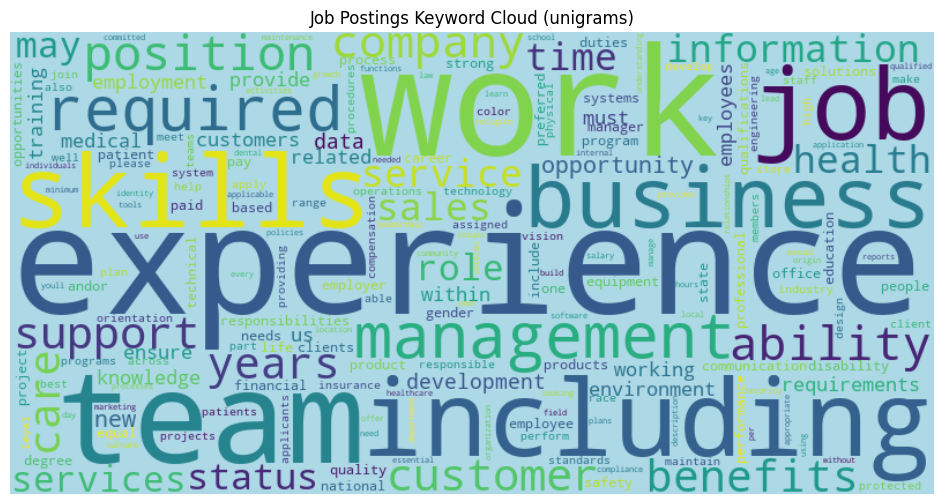

In [67]:
# JOB POSTING WORD CLOUD
job_desc = job_desc.apply(punct_preprocess)

job_freq = get_frequencies(job_desc)
job_wordcloud_1 = WordCloud(
    width = 800,
    height = 400,
    background_color = "lightblue"
).generate_from_frequencies(frequencies=job_freq)

plt.figure(figsize = (12, 6))
plt.imshow(job_wordcloud_1, interpolation="bilinear")
plt.axis("off")
plt.title("Job Postings Keyword Cloud (unigrams)")
plt.show()

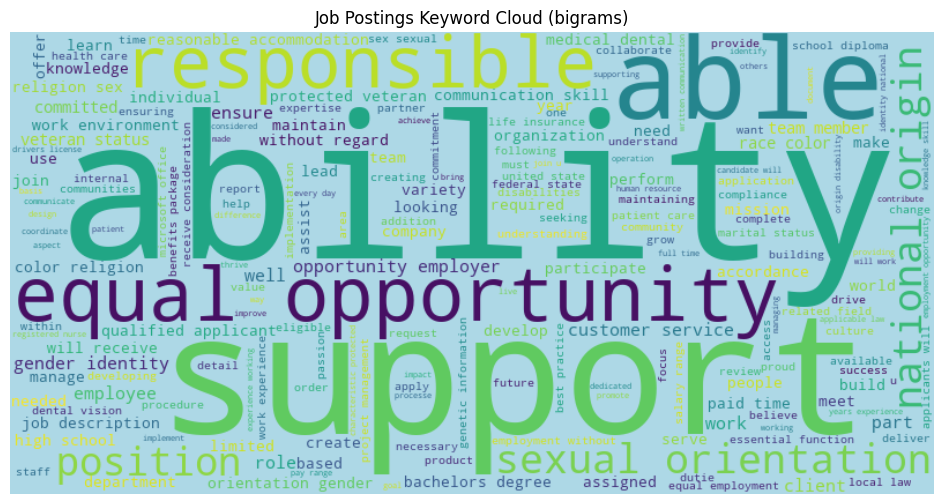

In [68]:
# JOB POSTING WORD CLOUD
long_string = " ".join(job_desc.astype(str))
job_wordcloud_2 = WordCloud(
    width = 800,
    height = 400,
    background_color = "lightblue"
).generate(long_string)

plt.figure(figsize = (12, 6))
plt.imshow(job_wordcloud_2, interpolation="bilinear")
plt.axis("off")
plt.title("Job Postings Keyword Cloud (bigrams)")
plt.show()

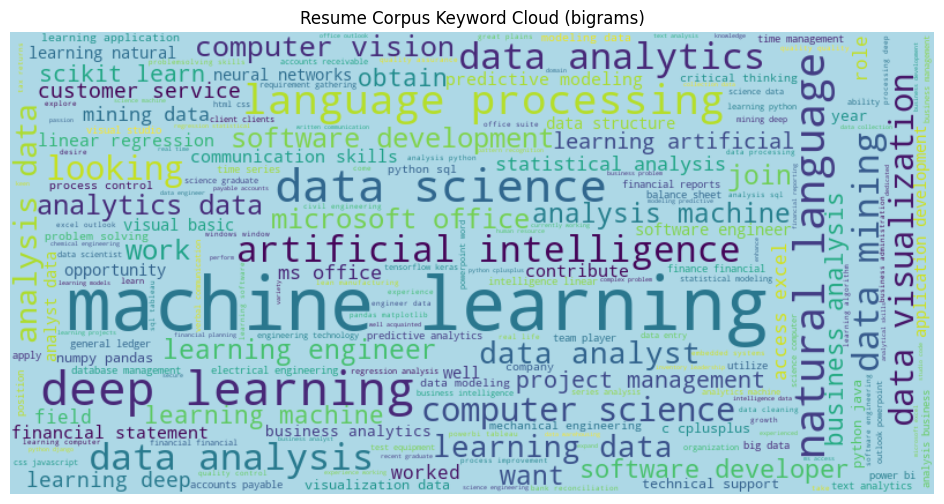

In [69]:
# RESUME WORD CLOUD
resume_desc = resume_desc.apply(punct_preprocess)
long_string = " ".join(resume_desc.astype(str))

res_wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = "lightblue"
).generate(long_string)

plt.figure(figsize = (12, 6))
plt.imshow(res_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Resume Corpus Keyword Cloud (bigrams)")
plt.show()

## Example resume for testing vectorization methods

In [70]:
resume_text_1 = resume_df['combined'].iloc[0]
print(resume_text_1)

resume_text_2 = """ 
# Alex Taylor San Francisco, CA | (555) 123-4567 | alex.taylor@email.com | linkedin.com/in/alextaylor | github.com/alextaylor
# Professional Summary Results-driven Software Engineer with 4+ years of experience designing and developing scalable web applications. Proficient in full-stack development with a strong focus on backend architecture, system optimization, and writing clean, maintainable code.
# Technical Skills
# Languages: Python, JavaScript (ES6+), Java, SQL
# Frameworks: React, Node.js, Django, Spring Boot
# Tools & Cloud: Git, Docker, Kubernetes, AWS (EC2, S3, RDS), CI/CD pipelines
# Professional Experience Software Engineer | TechNova Solutions June 2022 – Present
# Developed and deployed 5+ RESTful APIs using Node.js and Express, improving data retrieval speeds by 30%.
# Collaborated with cross-functional teams to migrate legacy monolithic architecture to microservices using Docker and AWS.
# Reduced application downtime by 15% through the implementation of automated testing and robust CI/CD pipelines.
# Junior Developer | CodeCrafters Inc. August 2020 – May 2022
# Built responsive frontend components using React, increasing mobile user engagement by 25%.
# Optimized database queries in PostgreSQL, reducing load times for the primary dashboard by 2 seconds.
# Education Bachelor of Science in Computer Science University of California, Berkeley | Graduated: May 2020
# """

Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them. Currently in search of role that offers more of development.['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure']['Electronics']


# TF-IDF

In [71]:
# TFIDF vectorizer 
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    ngram_range = (1,2), #include both unigrams and bigram
    max_features=10000, # Keeps only the top 10k most frequent n-grams
    min_df=2            # Ignores words that only appear in one single document
)

In [72]:
try:
    job_vectorized_tfidf = sp.load_npz('tfidf_job_vectors.npz')
    tfidf_vectorizer = joblib.load('tfidf_vectorizer.joblib')
    print("TFIDF vectors and vectorizer loaded successfully")

except FileNotFoundError:    
    # Fit and transform the data
    job_vectorized_tfidf = tfidf_vectorizer.fit_transform(job_df_processed['description'])
    
    # Save both files for the next run
    sp.save_npz('tfidf_job_vectors.npz', job_vectorized_tfidf)
    joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')

TFIDF vectors and vectorizer loaded successfully


In [73]:
def return_top_job_for_text_tfidf(resume_text, top, job_vectors, job_df, tfidf_vectorizer):
  '''
  find the top relevant job postings based on the resume
  Parameters
  ----------
  resume_text: string
    the text blob of a resume
  top: int
    the top number of matches to return

  Return
  ------
  results: list
    a list of dictionaries that contain the information about the top
    matches
  '''

  resume_vector = tfidf_vectorizer.transform([resume_text])

  # Compute Similarity using the single document vector
  similarity_scores = cosine_similarity(resume_vector, job_vectors)
  scores = similarity_scores[0]
  top_index = np.argsort(scores)[::-1] 

  results = []
  rank = 1
  seen_titles = set()

  # Iterate through all potential matches until you fill your 'top' requirement
  for job_index in top_index:
      title = job_df.iloc[job_index]['title']
      if title not in seen_titles:
          results.append({
              'Rank': rank,
              'Job Title': title,
              'Match Score': round(scores[job_index], 2)
          })
          seen_titles.add(title)
          rank += 1
      
      # Stop once the results list reaches the desired 'top' count (e.g., 10)
      if len(results) >= top:
          break
  return results

In [74]:
# example for the resume 1
results = return_top_job_for_text_tfidf(resume_text_1, 3, job_vectorized_tfidf, job_df_processed, tfidf_vectorizer)
for job in results:
  print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")
  
print("\n")
# example for the resume 2
results = return_top_job_for_text_tfidf(resume_text_2, 3, job_vectorized_tfidf, job_df_processed, tfidf_vectorizer)
for job in results:
  print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")

Score: 0.4400 | Title: Staff Data Engineer
Score: 0.4300 | Title: Data Scientist (Human Services experience)
Score: 0.4200 | Title: Data Science Analyst - Full Time


Score: 0.2800 | Title: Software Engineer
Score: 0.2600 | Title: Senior Frontend Developer
Score: 0.2500 | Title: Senior Software Engineer


In [75]:
resume_vectorized_tfidf = tfidf_vectorizer.transform(resume_df_processed['combined'])

In [76]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_scores_TFIDF = cosine_similarity(resume_vectorized_tfidf, job_vectorized_tfidf)

# Word2Vec

In [77]:
resume_tokens_word2vec = resume_df_processed['combined'].fillna("").str.lower().str.split().tolist()
job_tokens_word2vec =  job_df_processed['description'].fillna("").str.lower().str.split().tolist()

In [78]:
# Word2Vec model
try:
    model_word2vec = Word2Vec.load("word2vec.model")
except FileNotFoundError:
    print('training word2vec model')
    all_text_tokenized = resume_tokens_word2vec + job_tokens_word2vec

    model_word2vec = Word2Vec(sentences=all_text_tokenized, vector_size=300, window=5, min_count=1, workers=4)

    # Save model
    model_word2vec.save("word2vec.model")

In [79]:
def get_document_vector_word2vec(tokens, model):
    # Filter out words that are not in the model's vocabulary
    feature_vectors = [model.wv[word] for word in tokens if word in model.wv]

    # If the document is empty or no words match the vocabulary, return a zero vector
    if not feature_vectors:
        return np.zeros(model.vector_size)

    # Calculate the average of all word vectors
    return np.mean(feature_vectors, axis=0)

In [80]:
try:
    # load previously saved vectors
    resume_vectorized_word2vec = np.load('word2vec_resume_vectors.npy')
    job_vectorized_word2vec = np.load('word2vec_job_vectors.npy')
except FileNotFoundError:
    # Vectorize
    resume_vectorized_word2vec = np.array([get_document_vector_word2vec(it, model_word2vec) for it in resume_tokens_word2vec])
    job_vectorized_word2vec = np.array([get_document_vector_word2vec(it, model_word2vec) for it in job_tokens_word2vec])

    # Save the vectors to a file
    np.save('word2vec_resume_vectors.npy', resume_vectorized_word2vec)
    np.save('word2vec_job_vectors.npy', job_vectorized_word2vec)


In [81]:
similarity_scores_word2vec = cosine_similarity(resume_vectorized_word2vec, job_vectorized_word2vec)

In [82]:
def return_top_job_for_text_word2vec(resume_text, top, job_vectors, job_df, model):
  '''
  find the top relevant job postings based on the resume
  Parameters
  ----------
  resume_text: string
    the text blob of a resume
  top: int
    the top number of matches to return

  Return
  ------
  results: list
    a list of dictionaries that contain the information about the top
    matches
  '''
  resume_tokens = preprocess(resume_text).split() # Preprocess first!
  resume_vector = get_document_vector_word2vec(resume_tokens, model).reshape(1, -1)

  # Compute Similarity using the single document vector
  similarity_scores = cosine_similarity(resume_vector, job_vectors)
  scores = similarity_scores[0]
  top_index = np.argsort(scores)[::-1] 

  results = []
  rank = 1
  seen_titles = set()

  # Iterate through all potential matches until you fill your 'top' requirement
  for job_index in top_index:
      title = job_df.iloc[job_index]['title']
      if title not in seen_titles:
          results.append({
              'Rank': rank,
              'Job Title': title,
              'Match Score': round(scores[job_index], 2)
          })
          seen_titles.add(title)
          rank += 1
      
      # Stop once the results list reaches the desired 'top' count (e.g., 10)
      if len(results) >= top:
          break
  return results

In [83]:
# example for the resume 1
results = return_top_job_for_text_word2vec(resume_text_1, 3, job_vectorized_word2vec, job_df_processed, model_word2vec)
for job in results:
  print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")

print("\n")
# example for the resume 2
results = return_top_job_for_text_word2vec(resume_text_2, 3, job_vectorized_word2vec, job_df_processed, model_word2vec)
for job in results:
  print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")

Score: 0.9100 | Title: Java-Big Data Architect
Score: 0.9100 | Title: GCP Data Engineer- ONLY W2
Score: 0.9000 | Title: Azure Data Engineer


Score: 0.9300 | Title: java fullstack developer
Score: 0.9100 | Title: Dotnet Developer
Score: 0.9100 | Title: Full Stack Java Engineer


# SBERT

In [84]:
import os
import zipfile
import shutil
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
import torch
from transformers import logging as transformers_logging

# This silences the TQDM progress bars for downloading/loading weights
transformers_logging.set_verbosity_error()

# Automatically detect if a GPU is available, otherwise use CPU
if torch.cuda.is_available():
    print(f"GPU found: {torch.cuda.get_device_name(0)}")
    device = "cuda"
    batch_size = 64
else:
    print("No GPU detected.")
    device = "cpu"
    batch_size = 32

# Check if the zip file exists and unzip it if the directory doesn't exist yet
if os.path.exists("sbert.model.zip") and not os.path.exists("sbert.model"):
    print("Found zipped model, extracting...")
    with zipfile.ZipFile("sbert.model.zip", 'r') as zip_ref:
        zip_ref.extractall("sbert.model")

# Check if the model is already saved locally
if os.path.exists("sbert.model"):
    print("Loading SBERT model from local directory...")
    model_sentbert = SentenceTransformer("sbert.model", device=device)
else:
    print("Downloading SBERT model from Hugging Face...")
    model_sentbert = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2", device=device)
    model_sentbert.save("sbert.model")
    shutil.make_archive("sbert.model", 'zip', "sbert.model")

pool = model_sentbert.start_multi_process_pool()

try:
    resume_embeddings_sentbert = np.load('sentbert_resume_embeddings.npy',allow_pickle=True)
except FileNotFoundError:
    print('Embedding resume_embeddings_sentbert')
    resume_embeddings_sentbert = model_sentbert.encode(resume_df['combined'].tolist(), pool=pool, batch_size=batch_size, show_progress_bar=True)
    np.save('sentbert_resume_embeddings.npy', resume_embeddings_sentbert)

try:
    job_embeddings_sentbert = np.load('sentbert_job_embeddings.npy',allow_pickle=True)
except FileNotFoundError:
    print('Embedding job_embeddings_sentbert')
    job_embeddings_sentbert = model_sentbert.encode(job_df['description'].tolist(), pool=pool, batch_size=batch_size, show_progress_bar=True)
    np.save('sentbert_job_embeddings.npy', job_embeddings_sentbert)

model_sentbert.stop_multi_process_pool(pool)

No GPU detected.
Loading SBERT model from local directory...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [85]:
def return_top_job_for_text_sbert(resume_text, top, job_embeddings, job_df, sbert_model, batch_size):
  '''
  find the top relevant job postings based on the resume
  Parameters
  ----------
  resume_text: string
    the text blob of a resume
  top: int
    the top number of matches to return

  Return
  ------
  results: list
    a list of dictionaries that contain the information about the top
    matches
  '''
  resume_embeddings = sbert_model.encode(resume_text, batch_size=batch_size, show_progress_bar=False)

  # Compute Similarity using the single document vector
  similarity_scores = cosine_similarity_sbert(resume_embeddings, job_embeddings)
  scores = similarity_scores[0].cpu().numpy()
  # scores = similarity_scores[0]
  #  Get all indices sorted by score (remove [:top])
  top_index = np.argsort(scores)[::-1] 

  results = []
  rank = 1
  seen_titles = set()

  # Iterate through all potential matches until you fill your 'top' requirement
  for job_index in top_index:
      title = job_df.iloc[job_index]['title']
      if title not in seen_titles:
          results.append({
              'Rank': rank,
              'Job Title': title,
              'Match Score': round(scores[job_index], 2)
          })
          seen_titles.add(title)
          rank += 1
      
      # Stop once the results list reaches the desired 'top' count (e.g., 10)
      if len(results) >= top:
          break
  return results

In [86]:
# example for the resume 1
results = return_top_job_for_text_sbert(resume_text_1, 3, job_embeddings_sentbert, job_df, model_sentbert, batch_size=batch_size)
for job in results:
    print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")

print("\n")
# example for the resume 2
results = return_top_job_for_text_sbert(resume_text_2, 3, job_embeddings_sentbert, job_df, model_sentbert, batch_size=batch_size)
for job in results:
  print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")

Score: 0.7500 | Title: Senior Data Manager
Score: 0.7500 | Title: Cloud Data Engineer
Score: 0.7400 | Title: Senior Data Engineer


Score: 0.5800 | Title: Java Application Developer
Score: 0.5700 | Title: Sr. Java Engineer
Score: 0.5700 | Title: Software Engineer (E-Commerce ~ Javascript) ATX / Onsite / $65k


In [87]:
# Compute similarities between resume embeddings and job embeddings
similarity_scores_SENTBERT = cosine_similarity_sbert(resume_embeddings_sentbert, job_embeddings_sentbert)

# Glove



In [88]:
# GloVe vectorizer
class GloveVectorizer:
    def __init__(self, loaded_model):
        """
        Parameters:
        - model_name: name of the pre-trained GloVe model
        """
        self.model = loaded_model
        self.embedding_dim = self.model.vector_size

    def transform_word(self, word):
        """
        Return embedding for a single word (for visualization/debugging).
        """
        return self.model.get(word, np.zeros(self.embedding_dim))

    def transform(self, documents_tokens):
        """
        Convert tokenized documents into sentence vectors
        by averaging word embeddings.
        """
        vectors = []
        for tokens in documents_tokens:
            token_vectors = [
                self.model[token] for token in tokens if token in self.model
            ]
            if len(token_vectors) == 0:
                vectors.append(np.zeros(self.embedding_dim))
            else:
                vectors.append(np.mean(token_vectors, axis=0))
        return np.array(vectors)
    
glove_model_path = 'glove_model_200.kv'

# Handle the GloVe Model (Load locally or download if missing)
if os.path.exists(glove_model_path):
    print("Loading GloVe model from local storage...")
    glove_model_200 = KeyedVectors.load(glove_model_path)
else:
    print("Downloading GloVe model from API (this may take a minute)...")
    glove_model_200 = api.load("glove-wiki-gigaword-200")
    # Save natively using Gensim's optimized format
    glove_model_200.save(glove_model_path)
    print("GloVe model saved locally.")

# Initialize vectorizer with the model
glove_vectorizer = GloveVectorizer(glove_model_200)

GloVe model saved locally.


In [89]:
job_tokens_glove = job_df_processed['description'].fillna("").str.lower().str.split().tolist()
resume_tokens_glove = resume_df_processed['combined'].fillna("").str.lower().str.split().tolist()

try:
    job_vectorized_glove = np.load('glove_job_vectors.npy',allow_pickle=True)
except FileNotFoundError:
    print('Vectorizing job_vectorized_glove')
    job_vectorized_glove = glove_vectorizer.transform(job_tokens_glove)
    np.save('glove_job_vectors.npy', job_vectorized_glove)
try:
    resume_vectorized_glove = np.load('glove_resume_vectors.npy',allow_pickle=True)
except FileNotFoundError:
    print('Vectorizing resume_vectorized_glove')
    resume_vectorized_glove = glove_vectorizer.transform(resume_tokens_glove)
    np.save('glove_resume_vectors.npy', resume_vectorized_glove)

In [90]:
def return_top_job_for_text_glove(resume_text, top, job_vectors, job_df, glove_vectorizer):
  '''
  find the top relevant job postings based on the resume
  Parameters
  ----------
  resume_text: string
    the text blob of a resume
  top: int
    the top number of matches to return

  Return
  ------
  results: list
    a list of dictionaries that contain the information about the top
    matches
  '''

  resume_tokens = preprocess(resume_text).lower().split() 
  resume_vector = glove_vectorizer.transform([resume_tokens])
  # Compute Similarity using the single document vector
  similarity_scores = cosine_similarity(resume_vector, job_vectors)
  scores = similarity_scores[0]
  top_index = np.argsort(scores)[::-1] 

  results = []
  rank = 1
  seen_titles = set()

  # Iterate through all potential matches until you fill your 'top' requirement
  for job_index in top_index:
      title = job_df.iloc[job_index]['title']
      if title not in seen_titles:
          results.append({
              'Rank': rank,
              'Job Title': title,
              'Match Score': round(scores[job_index], 2)
          })
          seen_titles.add(title)
          rank += 1
      
      # Stop once the results list reaches the desired 'top' count (e.g., 10)
      if len(results) >= top:
          break
  return results

In [91]:
# example for the resume 1
results = return_top_job_for_text_glove(resume_text_1, 3, job_vectorized_glove, job_df_processed, glove_vectorizer)
for job in results:
    print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")
    
print("\n")
# example for the resume 2
results = return_top_job_for_text_glove(resume_text_2, 3, job_vectorized_glove, job_df_processed, glove_vectorizer)
for job in results:
  print(f"Score: {job['Match Score']:.4f} | Title: {job['Job Title']}")

Score: 0.9200 | Title: Data Engineer
Score: 0.9200 | Title: Senior Data Engineer (Azure, Python, SQL)
Score: 0.9200 | Title: Enterprise Data Engineer (Azure, Python, SQL)


Score: 0.9400 | Title: Prog Analyst PowerBI/GIS- Nearby VA
Score: 0.9400 | Title: Program Analyst Power BI
Score: 0.9300 | Title: Mobile Java Developer


In [92]:
# Compute similarities between resume embeddings and job embeddings
similarity_scores_glove = cosine_similarity(resume_vectorized_glove, job_vectorized_glove)

# Bert Score

## BERTScore @ 1

In [93]:
def predict_job_using_matrix(cosine_matrix):
  # Optimize by using vectorized np.argmax to find the max index across the entire matrix at once
  top_indices = np.argmax(cosine_matrix, axis=1)

  # Map the indices directly to the job titles
  prediction = job_df_processed.iloc[top_indices]['title'].tolist()

  return prediction

In [94]:
def predict_job_using_matrix_sbert(cosine_matrix):
  '''
  return the top prediction for each resume as a list
  '''
  top_indices = torch.topk(cosine_matrix, k=1, dim=1).indices.flatten().tolist()

  prediction = job_df_processed.iloc[top_indices]['title'].tolist()

  return prediction


In [95]:
predicted_job_TFIDF = predict_job_using_matrix(similarity_scores_TFIDF)
predicted_job_word2vec = predict_job_using_matrix(similarity_scores_word2vec)
predicted_job_glove = predict_job_using_matrix(similarity_scores_glove)
predicted_job_sbert = predict_job_using_matrix_sbert(similarity_scores_SENTBERT)

true_job = resume_df['job_position_name'].tolist()

In [96]:
from bert_score import score
P_TFIDF, R_TFIDF, F1_TFIDF = score(predicted_job_TFIDF, true_job, lang="en", verbose=False)

P_word2vec, R_word2vec, F1_word2vec = score(predicted_job_word2vec, true_job, lang="en", verbose=False)

# # Flatten predicted_job_glove to match the format of true_job
# predicted_job_glove = [title[0] for title in predicted_job_glove]
# P_glove, R_glove, F1_glove = score(predicted_job_glove, true_job, lang="en", verbose=False)

P_glove, R_glove, F1_glove = score(predicted_job_glove, true_job, lang="en", verbose=False)

P_bert, R_bert, F1_bert = score(predicted_job_sbert, true_job, lang="en", verbose=False)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

In [97]:
print('Bert Score for models @1:')
print('-' * 50)
print('Vectorization: TFIDF')
print('-'* 20)
print(f"Bert precision: {P_TFIDF.mean()}")
print(f"Bert recall: {R_TFIDF.mean()}")
print(f"Bert F1 Score: {F1_TFIDF.mean()}")
print('-' * 40)


print('Model: Word2Vec')
print('-'* 20)
print(f"Bert precision: {P_word2vec.mean()}")
print(f"Bert recall: {R_word2vec.mean()}")
print(f"Bert F1 Score: {F1_word2vec.mean()}")
print('-' * 40)


print('Model: Sentence Bert')
print('-'* 20)
print(f"Bert precision: {P_bert.mean()}")
print(f"Bert recall: {R_bert.mean()}")
print(f"Bert F1 Score: {F1_bert.mean()}")
print('-' * 40)


print('Model: Glove')
print('-'* 20)
print(f"Bert precision: {P_glove.mean()}")
print(f"Bert recall: {R_glove.mean()}")
print(f"Bert F1 Score: {F1_glove.mean()}")


Bert Score for models @1:
--------------------------------------------------
Vectorization: TFIDF
--------------------
Bert precision: 0.8646417260169983
Bert recall: 0.8722063899040222
Bert F1 Score: 0.868127703666687
----------------------------------------
Model: Word2Vec
--------------------
Bert precision: 0.8637657761573792
Bert recall: 0.8739368319511414
Bert F1 Score: 0.8684725761413574
----------------------------------------
Model: Sentence Bert
--------------------
Bert precision: 0.864632248878479
Bert recall: 0.8686292171478271
Bert F1 Score: 0.866388738155365
----------------------------------------
Model: Glove
--------------------
Bert precision: 0.8685150146484375
Bert recall: 0.8710634708404541
Bert F1 Score: 0.8695387244224548


## BERTScore @ 5

In [98]:
def predict_top_5(cosine_matrix):
    # np.argsort sorts low to high, so we take the last 5 indices [:, -5:]
    # Then we reverse them [:, ::-1] so the #1 match is first
    top_5_indices = np.argsort(cosine_matrix, axis=1)[:, -5:][:, ::-1]
    
    # This creates a list of lists (each sub-list contains 5 titles)
    predictions = [job_df_processed.iloc[indices]['title'].tolist() for indices in top_5_indices]
    return predictions



In [99]:
def predict_top_5_sbert(cosine_matrix):
    # Simply change k=1 to k=5
    top_indices = torch.topk(cosine_matrix, k=5, dim=1).indices
    
    # Create a list of lists of titles
    predictions = [job_df_processed.iloc[row.tolist()]['title'].tolist() for row in top_indices]
    return predictions

In [100]:
predicted_top_5_TFIDF = predict_top_5(similarity_scores_TFIDF)

predicted_top_5_word2vec = predict_top_5(similarity_scores_word2vec)

predicted_top_5_glove = predict_top_5(similarity_scores_glove)

predicted_top_5_sbert = predict_top_5_sbert(similarity_scores_SENTBERT)

true_job = resume_df['job_position_name'].tolist()

In [101]:
# Flatten predictions into one long list
flattened_preds_tfidf = [item for sublist in predicted_top_5_TFIDF for item in sublist]
flattened_preds_word2vec = [item for sublist in predicted_top_5_word2vec for item in sublist]
flattened_preds_glove = [item for sublist in predicted_top_5_glove for item in sublist]
flattened_preds_sbert = [item for sublist in predicted_top_5_sbert for item in sublist]

# Repeat  true labels 5 times each to match the length
# Example: [JobA, JobB] becomes [JobA, JobA, JobA, JobA, JobA, JobB, JobB, JobB, JobB, JobB]
repeated_true = np.repeat(true_job, 5).tolist()


P_TFIDF, R_TFIDF, F1_TFIDF = score(flattened_preds_tfidf, repeated_true, lang="en", verbose=False)

P_word2vec, R_word2vec, F1_word2vec = score(flattened_preds_word2vec, repeated_true, lang="en", verbose=False)

P_glove, R_glove, F1_glove = score(flattened_preds_glove, repeated_true, lang="en", verbose=False)

P_bert, R_bert, F1_bert = score(flattened_preds_glove, flattened_preds_sbert, lang="en", verbose=False)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

In [102]:
print('Bert Score for models @5:')
print('-' * 50)
print('Vectorization: TFIDF')
print('-'* 20)
print(f"Bert precision: {P_TFIDF.mean()}")
print(f"Bert recall: {R_TFIDF.mean()}")
print(f"Bert F1 Score: {F1_TFIDF.mean()}")
print('-' * 40)


print('Model: Word2Vec')
print('-'* 20)
print(f"Bert precision: {P_word2vec.mean()}")
print(f"Bert recall: {R_word2vec.mean()}")
print(f"Bert F1 Score: {F1_word2vec.mean()}")
print('-' * 40)


print('Model: Sentence Bert')
print('-'* 20)
print(f"Bert precision: {P_bert.mean()}")
print(f"Bert recall: {R_bert.mean()}")
print(f"Bert F1 Score: {F1_bert.mean()}")
print('-' * 40)


print('Model: Glove')
print('-'* 20)
print(f"Bert precision: {P_glove.mean()}")
print(f"Bert recall: {R_glove.mean()}")
print(f"Bert F1 Score: {F1_glove.mean()}")


Bert Score for models @5:
--------------------------------------------------
Vectorization: TFIDF
--------------------
Bert precision: 0.8636709451675415
Bert recall: 0.8711075782775879
Bert F1 Score: 0.8670907616615295
----------------------------------------
Model: Word2Vec
--------------------
Bert precision: 0.8666738271713257
Bert recall: 0.873866617679596
Bert F1 Score: 0.8699389696121216
----------------------------------------
Model: Sentence Bert
--------------------
Bert precision: 0.8648984432220459
Bert recall: 0.8655354976654053
Bert F1 Score: 0.8649556636810303
----------------------------------------
Model: Glove
--------------------
Bert precision: 0.8643481731414795
Bert recall: 0.8692013025283813
Bert F1 Score: 0.8665174841880798
